# HyDMIS, TruthSeeker EDA
## Social Media Disinformation Domain

**Dataset:** TruthSeeker, Dadkhah et al. (2023), IEEE TCSS  
**Records:** 134,198  
**Labels:** Binary (credible/disinformation) + 5-way crowd + 3-way crowd  
**Domain:** Social Media, English  

**Unique structure:** Each record has both a statement AND a tweet response, dual-text.  

**Label mapping:**
- BinaryNumTarget=1 (target=True) = Credible
- BinaryNumTarget=0 (target=False) = Disinformation
- binary_label flipped for HyDMIS consistency: 1=disinformation

**Key findings:** Near-balanced (48.6% disinformation). Author identity is strong signal, some authors show 100% disinformation rate. Biden/Trump/vaccine dominate keywords.

In [1]:
import sys
import os
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from truthseeker_loader import load_truthseeker

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)

FIVE_LABELS = ['Agree','Mostly Agree','NO MAJORITY','Mostly Disagree','Disagree']
FIVE_COLORS = ['#5cb85c','#90EE90','#f0ad4e','#FF7F7F','#d9534f']
print('Imports complete')

Imports complete


In [2]:
result = load_truthseeker(data_dir='../data/raw')
df = result['data']
df['binary_label'] = 1 - df['BinaryNumTarget']  # 1=disinformation, 0=credible
df['stmt_len'] = df['statement'].astype(str).str.len()
df['tweet_len'] = df['tweet'].astype(str).str.len()

print(f'Shape: {df.shape}')
print(f'Disinformation rate: {df["binary_label"].mean():.1%}')
print(f'Records: {len(df):,}')

Loading TruthSeeker...


   TruthSeeker: 134,198 records | Social Media | English
Shape: (134198, 12)
Disinformation rate: 48.6%
Records: 134,198


## 1. Binary Label Distribution, Near-Balanced

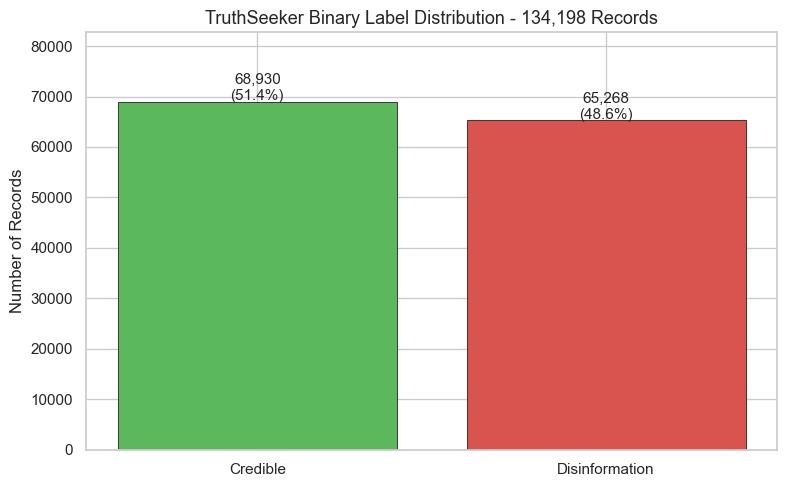

Near-balanced: 51.4% credible vs 48.6% disinformation, no severe class imbalance


In [3]:
credible = (df['BinaryNumTarget']==1).sum()
disinfo = (df['BinaryNumTarget']==0).sum()

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(['Credible','Disinformation'], [credible, disinfo],
              color=['#5cb85c','#d9534f'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, [credible, disinfo]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=11)
ax.set_title('TruthSeeker Binary Label Distribution - 134,198 Records', fontsize=13)
ax.set_ylabel('Number of Records')
ax.set_ylim(0, max(credible,disinfo)*1.2)
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Near-balanced: 51.4% credible vs 48.6% disinformation, no severe class imbalance')

## 2. Five-Way Label Distribution

Unique crowd annotation, Agree/Mostly Agree/NO MAJORITY/Mostly Disagree/Disagree.

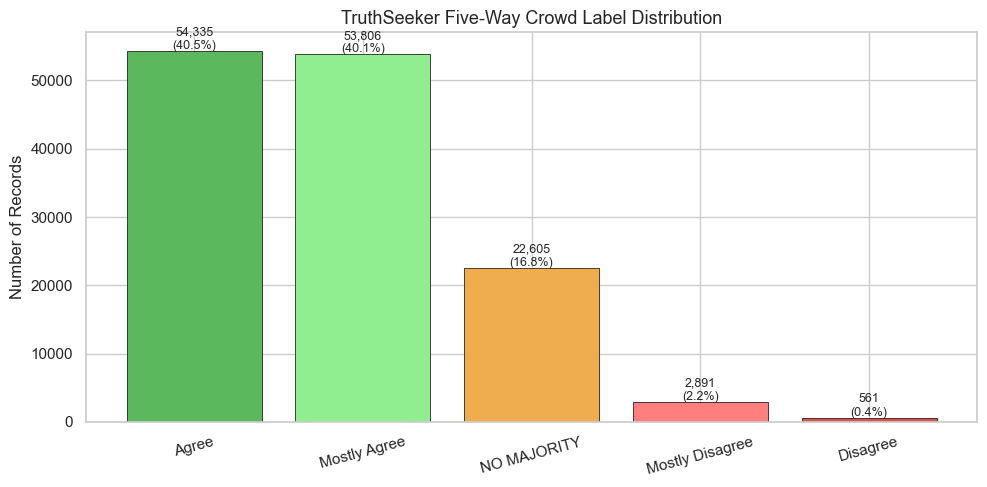

NO MAJORITY (16.8%), ambiguous cases need special handling in HyDMIS Stage 1


In [4]:
five_counts = df['5_label_majority_answer'].value_counts().reindex(FIVE_LABELS).fillna(0)

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(FIVE_LABELS, five_counts.values, color=FIVE_COLORS,
              edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, five_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
            f'{int(val):,}\n({val/len(df):.1%})', ha='center', fontsize=9)
ax.set_title('TruthSeeker Five-Way Crowd Label Distribution', fontsize=13)
ax.set_ylabel('Number of Records')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_five_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('NO MAJORITY (16.8%), ambiguous cases need special handling in HyDMIS Stage 1')

## 3. Three-Way Label Distribution

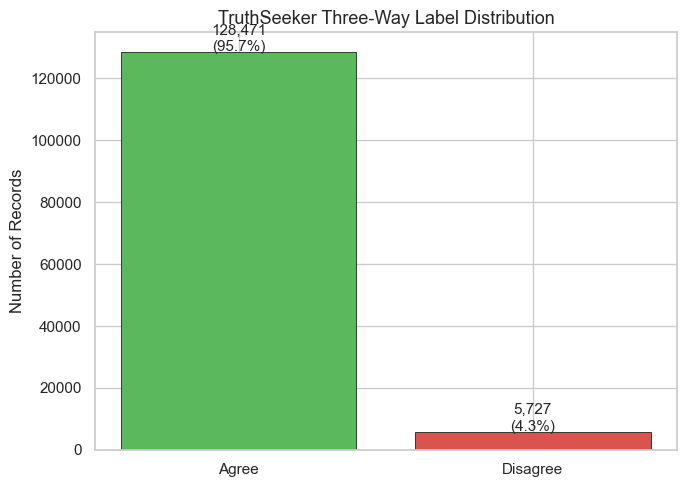

3-way Agree 95.7% vs Disagree 4.3%, highly skewed when collapsed


In [5]:
three_counts = df['3_label_majority_answer'].value_counts()

fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(three_counts.index, three_counts.values,
              color=['#5cb85c','#d9534f'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, three_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500,
            f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=11)
ax.set_title('TruthSeeker Three-Way Label Distribution', fontsize=13)
ax.set_ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_three_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('3-way Agree 95.7% vs Disagree 4.3%, highly skewed when collapsed')

## 4. Top 15 Authors by Disinformation Rate

Author identity is a strong signal, some authors show 100% or 0% disinformation rates.

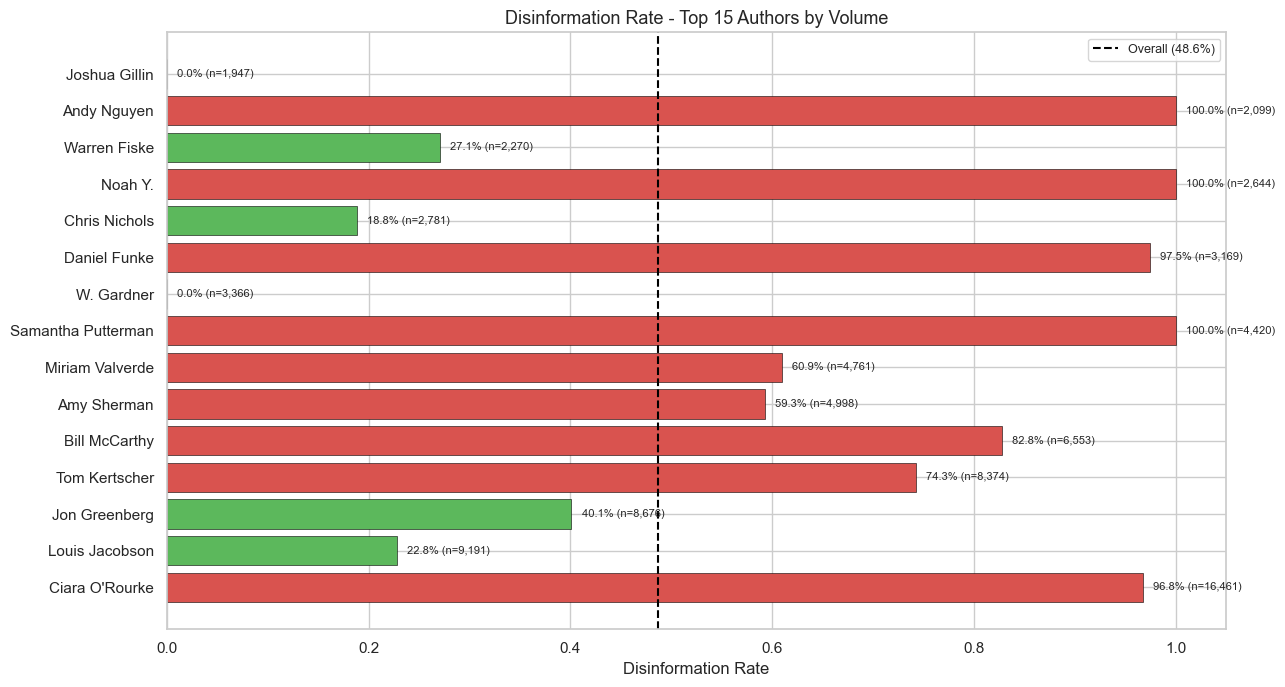

Samantha Putterman 100%, W. Gardner 0%, author encodes systematic bias


In [6]:
author_stats = df.groupby('author').agg(
    count=('binary_label','count'),
    dis_rate=('binary_label','mean')
).reset_index().sort_values('count', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13,7))
colors = ['#d9534f' if r > 0.5 else '#5cb85c' for r in author_stats['dis_rate']]
bars = ax.barh(author_stats['author'], author_stats['dis_rate'],
               color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(x=df['binary_label'].mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall ({df["binary_label"].mean():.1%})')
ax.set_title('Disinformation Rate - Top 15 Authors by Volume', fontsize=13)
ax.set_xlabel('Disinformation Rate')
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, author_stats.iterrows()):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'{row["dis_rate"]:.1%} (n={int(row["count"]):,})', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_authors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Samantha Putterman 100%, W. Gardner 0%, author encodes systematic bias')

## 5. Statement Length by Label

Disinformation statements longer (mean 97 chars) than credible (mean 81 chars). r=-0.192.

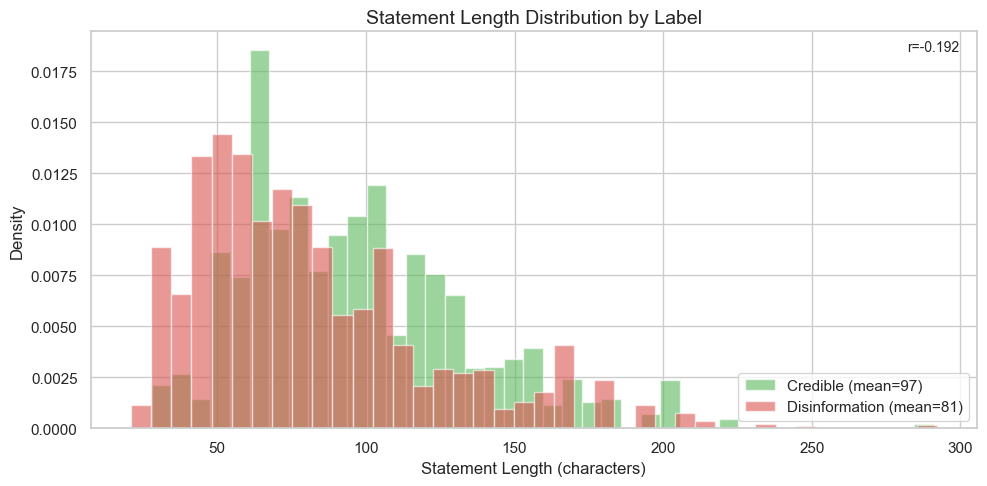

In [7]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df[df['binary_label']==0]['stmt_len'], bins=40, alpha=0.6,
        color='#5cb85c', label=f'Credible (mean={df[df["binary_label"]==0]["stmt_len"].mean():.0f})', density=True)
ax.hist(df[df['binary_label']==1]['stmt_len'], bins=40, alpha=0.6,
        color='#d9534f', label=f'Disinformation (mean={df[df["binary_label"]==1]["stmt_len"].mean():.0f})', density=True)
ax.set_title('Statement Length Distribution by Label', fontsize=14)
ax.set_xlabel('Statement Length (characters)')
ax.set_ylabel('Density')
ax.legend()
corr = df['stmt_len'].corr(df['binary_label'])
ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_statement_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tweet Length by Label

Credible tweets slightly longer (224 chars) vs disinformation (211 chars). Weaker signal than statement length.

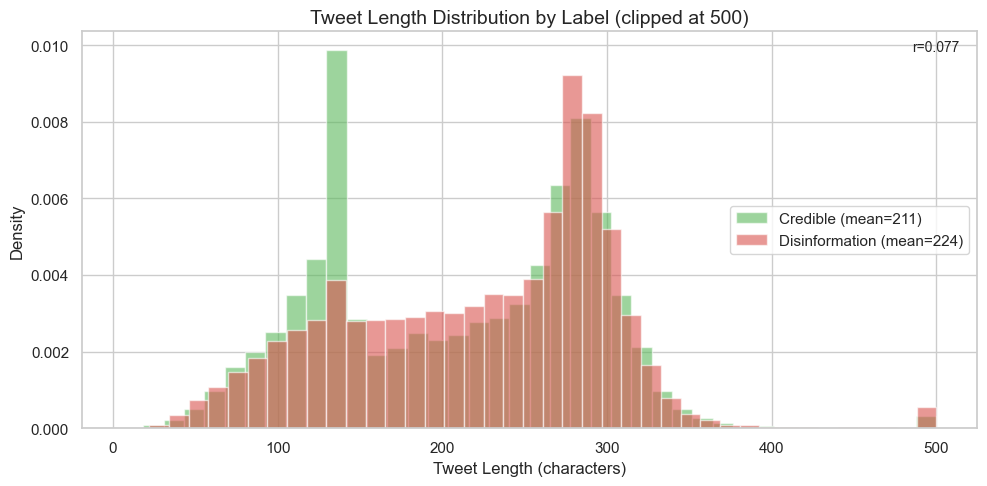

In [8]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df[df['binary_label']==0]['tweet_len'].clip(upper=500), bins=40, alpha=0.6,
        color='#5cb85c', label=f'Credible (mean={df[df["binary_label"]==0]["tweet_len"].mean():.0f})', density=True)
ax.hist(df[df['binary_label']==1]['tweet_len'].clip(upper=500), bins=40, alpha=0.6,
        color='#d9534f', label=f'Disinformation (mean={df[df["binary_label"]==1]["tweet_len"].mean():.0f})', density=True)
ax.set_title('Tweet Length Distribution by Label (clipped at 500)', fontsize=14)
ax.set_xlabel('Tweet Length (characters)')
ax.set_ylabel('Density')
ax.legend()
corr = df['tweet_len'].corr(df['binary_label'])
ax.text(0.98, 0.95, f'r={corr:.3f}', transform=ax.transAxes, fontsize=10, ha='right')
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_tweet_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Author Disinformation Rate Distribution

Bimodal, many authors near 0% or 100%. Author identity encodes systematic bias.

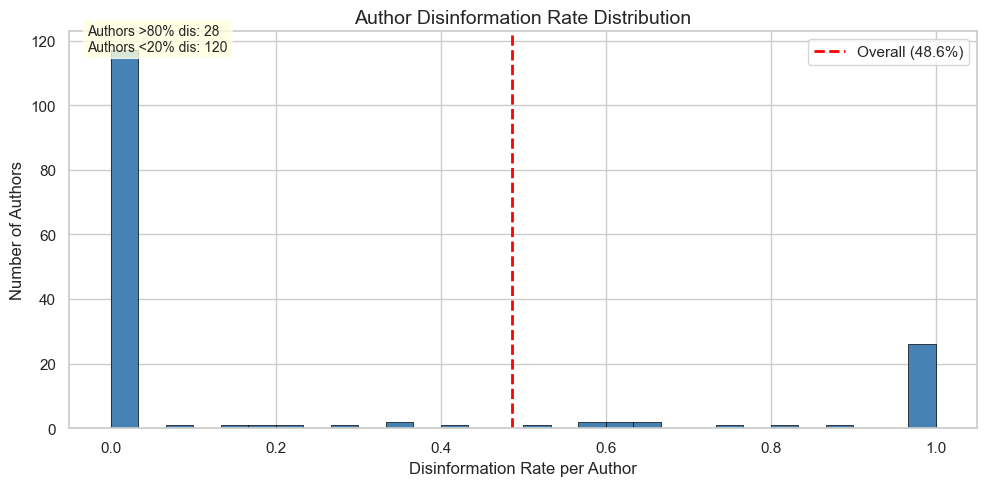

In [9]:
author_dis = df.groupby('author')['binary_label'].mean()

fig, ax = plt.subplots(figsize=(10,5))
ax.hist(author_dis, bins=30, color='steelblue', edgecolor='black', linewidth=0.5)
ax.axvline(x=df['binary_label'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Overall ({df["binary_label"].mean():.1%})')
ax.set_title('Author Disinformation Rate Distribution', fontsize=14)
ax.set_xlabel('Disinformation Rate per Author')
ax.set_ylabel('Number of Authors')
ax.legend()
ax.text(0.02, 0.95, f'Authors >80% dis: {(author_dis>0.8).sum()}\nAuthors <20% dis: {(author_dis<0.2).sum()}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_author_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Top Keywords, Biden/Trump/Vaccine Dominate

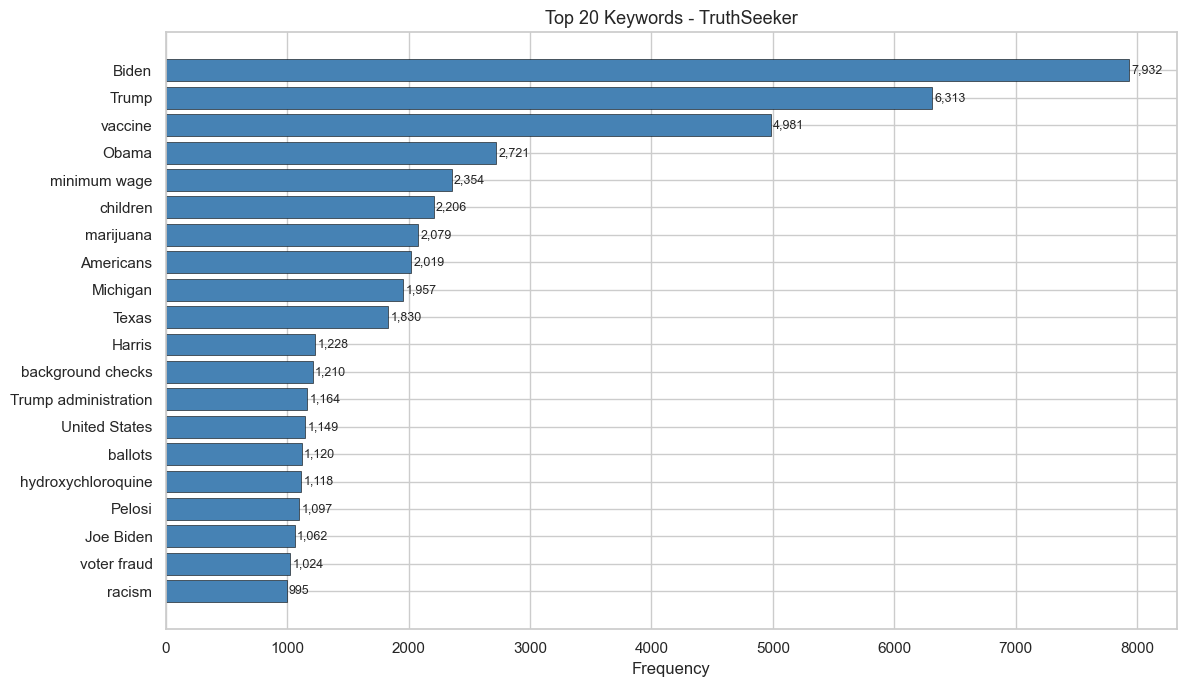

Biden (7,932), Trump (6,313), vaccine (4,981), politically charged topics dominate


In [10]:
all_keywords = df['manual_keywords'].dropna().str.split(',').explode().str.strip()
kw_counts = all_keywords.value_counts().head(20)

fig, ax = plt.subplots(figsize=(12,7))
ax.barh(kw_counts.index[::-1], kw_counts.values[::-1],
        color='steelblue', edgecolor='black', linewidth=0.4)
ax.set_title('Top 20 Keywords - TruthSeeker', fontsize=13)
ax.set_xlabel('Frequency')
for i, val in enumerate(kw_counts.values[::-1]):
    ax.text(val+20, i, f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_keywords.png', dpi=150, bbox_inches='tight')
plt.show()
print('Biden (7,932), Trump (6,313), vaccine (4,981), politically charged topics dominate')

## 9. Statement vs Tweet Length, Dual-Text Relationship

TruthSeeker unique structure, both statement and tweet available per record.

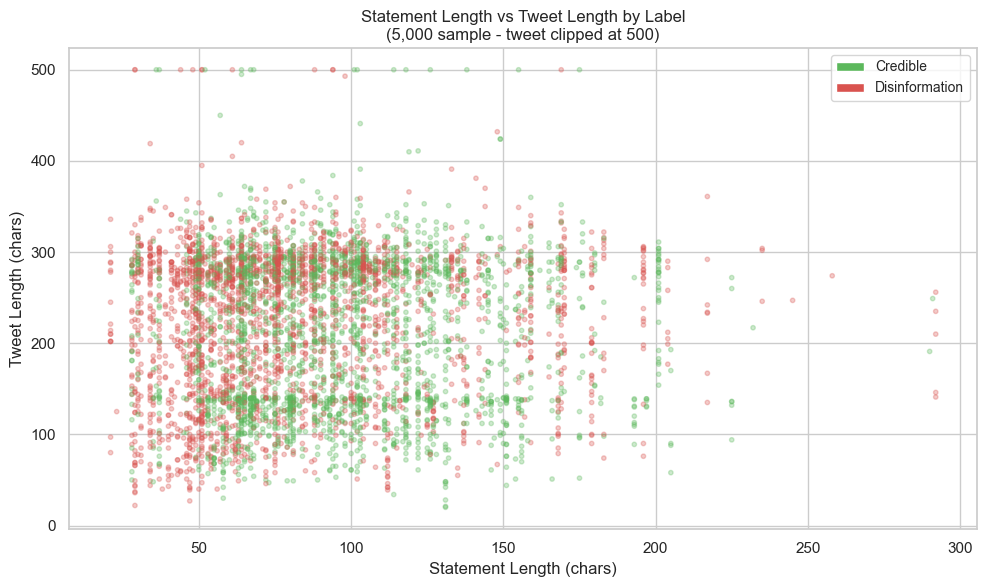

Dual-text structure unique to TruthSeeker, HyDMIS Stage 1 uses both text fields


In [11]:
sample = df.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10,6))
colors = ['#5cb85c' if l==0 else '#d9534f' for l in sample['binary_label']]
ax.scatter(sample['stmt_len'], sample['tweet_len'].clip(upper=500),
           c=colors, alpha=0.3, s=10)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#5cb85c', label='Credible'),
                   Patch(facecolor='#d9534f', label='Disinformation')]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_title('Statement Length vs Tweet Length by Label\n(5,000 sample - tweet clipped at 500)',
             fontsize=12)
ax.set_xlabel('Statement Length (chars)')
ax.set_ylabel('Tweet Length (chars)')
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_dual_text.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dual-text structure unique to TruthSeeker, HyDMIS Stage 1 uses both text fields')

## 10. NO MAJORITY Analysis

NO MAJORITY cases (16.8%) are ambiguous crowd annotations. Need special handling in HyDMIS Stage 1.

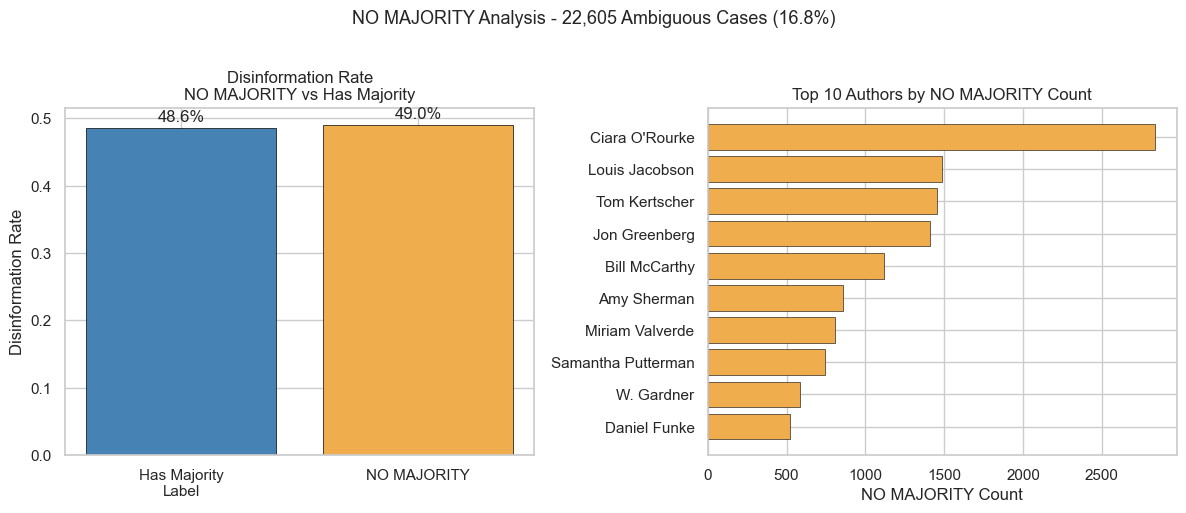

NO MAJORITY disinformation rate: 49.0% vs majority cases: 48.6%


In [12]:
no_majority = df[df['5_label_majority_answer']=='NO MAJORITY']
has_majority = df[df['5_label_majority_answer']!='NO MAJORITY']

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))

# Binary label distribution for NO MAJORITY vs has majority
nm_dis = no_majority['binary_label'].mean()
hm_dis = has_majority['binary_label'].mean()
ax1.bar(['Has Majority\nLabel','NO MAJORITY'], [hm_dis, nm_dis],
        color=['steelblue','#f0ad4e'], edgecolor='black', linewidth=0.5)
ax1.set_title('Disinformation Rate\nNO MAJORITY vs Has Majority', fontsize=12)
ax1.set_ylabel('Disinformation Rate')
for i, val in enumerate([hm_dis, nm_dis]):
    ax1.text(i, val+0.01, f'{val:.1%}', ha='center', fontsize=12)

# NO MAJORITY by author, top 10
nm_by_author = no_majority.groupby('author').size().sort_values(ascending=False).head(10)
ax2.barh(nm_by_author.index[::-1], nm_by_author.values[::-1],
         color='#f0ad4e', edgecolor='black', linewidth=0.4)
ax2.set_title('Top 10 Authors by NO MAJORITY Count', fontsize=12)
ax2.set_xlabel('NO MAJORITY Count')

plt.suptitle('NO MAJORITY Analysis - 22,605 Ambiguous Cases (16.8%)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_no_majority.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'NO MAJORITY disinformation rate: {nm_dis:.1%} vs majority cases: {hm_dis:.1%}')

## 11. Keywords by Label, Disinformation vs Credible

Disinformation keywords: Biden, vaccine, children, Michigan, ballots, hydroxychloroquine, COVID + election misinformation.  
Credible keywords: Trump, Obama, minimum wage, marijuana, Americans, policy topics.

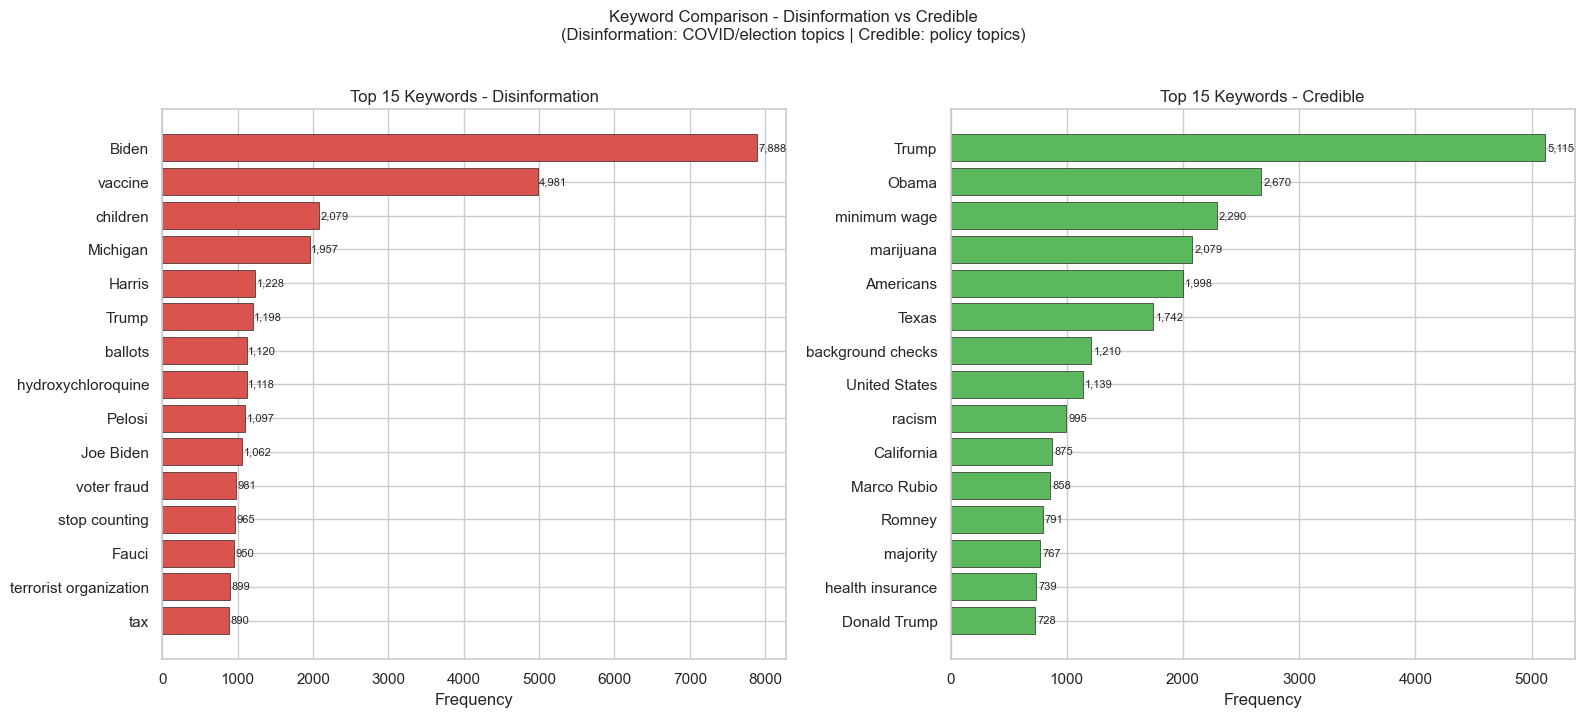

Disinformation: vaccine/ballots/hydroxychloroquine, COVID+election misinformation
Credible: minimum wage/marijuana/background checks, policy debates


In [13]:
dis_kw = df[df['binary_label']==1]['manual_keywords'].dropna().str.split(',').explode().str.strip()
cred_kw = df[df['binary_label']==0]['manual_keywords'].dropna().str.split(',').explode().str.strip()

dis_top = dis_kw.value_counts().head(15)
cred_top = cred_kw.value_counts().head(15)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,7))

ax1.barh(dis_top.index[::-1], dis_top.values[::-1],
         color='#d9534f', edgecolor='black', linewidth=0.4)
ax1.set_title('Top 15 Keywords - Disinformation', fontsize=12)
ax1.set_xlabel('Frequency')
for i, val in enumerate(dis_top.values[::-1]):
    ax1.text(val+20, i, f'{val:,}', va='center', fontsize=8)

ax2.barh(cred_top.index[::-1], cred_top.values[::-1],
         color='#5cb85c', edgecolor='black', linewidth=0.4)
ax2.set_title('Top 15 Keywords - Credible', fontsize=12)
ax2.set_xlabel('Frequency')
for i, val in enumerate(cred_top.values[::-1]):
    ax2.text(val+20, i, f'{val:,}', va='center', fontsize=8)

plt.suptitle('Keyword Comparison - Disinformation vs Credible\n'
             '(Disinformation: COVID/election topics | Credible: policy topics)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/truthseeker_keyword_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Disinformation: vaccine/ballots/hydroxychloroquine, COVID+election misinformation')
print('Credible: minimum wage/marijuana/background checks, policy debates')

## 12. Key Observations

**Near-balanced dataset:** 48.6% disinformation vs 51.4% credible, no severe class imbalance. Unlike LIAR2 (57.7%), TruthSeeker is more evenly split.

**Author identity as strong signal:** Some authors show 100% (Samantha Putterman, Noah Y., Andy Nguyen) or 0% (W. Gardner, Joshua Gillin) disinformation rates. 28 authors >80% dis rate, 120 authors <20% dis rate, bimodal distribution.

**Statement length signal:** Disinformation statements longer (97 chars) than credible (81 chars), r=-0.192. Stronger signal than tweet length (r=0.077).

**Politically charged keywords:** Biden (7,932), Trump (6,313), vaccine (4,981) dominate. Consistent with social media disinformation landscape.

**NO MAJORITY cases (16.8%):** 22,605 ambiguous crowd annotations. HyDMIS Stage 1 LDA will treat these as a separate uncertainty class.

**Dual-text structure:** Statement + tweet response per record, unique to TruthSeeker. HyDMIS Stage 1 LDA uses both text fields for topic modeling.